# Masked MLP Pretraining Test

Drop-in MLP baseline for `MaskedLatentPretrainer`. Same contract — SC+FC PCA-component tokens, learned `sc_mask_value`/`fc_mask_value` fills, masked-MSE objective on held-out positions, and a `forward(x)` zero-shot SC→FC probe. The attention stack is replaced by a flat MLP encoder and two per-modality decoder heads.

Goal: isolate whether the ~0.5 masked-MSE plateau on the attention path is architectural (capacity, softmax kernel, mask-visibility) or the PCA-decorrelation structural limit noted in CONTEXT.md. If even a sufficiently large MLP plateaus, the limit is real. If the MLP breaks below it, attention tuning is the bottleneck.

Three runs in this notebook:
1. **Pure linear** — `nonlinear=False`, single `Linear(2k → hidden)`. Lower bound for a linear reconstruction map.
2. **Low-rank linear** — `nonlinear=False` with `low_rank_dim=R`, giving two linear layers composed through a bottleneck. Rank-constrained linear.
3. **Nonlinear MLP** — `nonlinear=True` with hidden PReLU layers. Tests whether capacity above linear helps.

In [37]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

import main
import models.registry
import models.train.loss
import models.train.lightning_module
import models.eval.evaluator
import models.eval.pretrain_eval
import models.architectures.latent_attention.masked_mlp_pretrainer

importlib.reload(models.train.loss)
importlib.reload(models.train.lightning_module)
importlib.reload(models.eval.evaluator)
importlib.reload(models.eval.pretrain_eval)
importlib.reload(models.architectures.latent_attention.masked_mlp_pretrainer)
importlib.reload(models.registry)
importlib.reload(main)

from main import Sim
from models.eval.pretrain_eval import (
    collect_component_stats,
    diagnose_split,
    plot_best_worst_component_scatter,
    plot_component_metric_grid,
    plot_cross_model_component_metric,
)

RESULTS_ROOT = Path("results/local_results")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"


### Instantiate Sim

Built once; we swap the model config on each `run_single` call via `config_override`.

In [25]:
sim = Sim(
    model_name="MaskedMLPPretrainer",
    source="SC",
    target="FC",
    parcellation="Glasser",
    shuffle_seed=0,
    data_load_mode="precomputed",
)

/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 1. Pure linear baseline

`nonlinear=False`, no `low_rank_dim`. A single `Linear(2k → hidden)` encoder followed by two linear heads — as expressive as any affine map from flat scalars to per-modality reconstructions. If this can't break below the attention plateau, the limit is structural.

MaskedMLPPretrainer init | src=SC tgt=FC | k=128 hidden_dim=128 num_hidden_layers=1 | nonlinear=False low_rank_dim=None readout=linear | zscore=True sc_p=0.2 fc_p=0.2 | use_cov=False


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /scratch/asr655/neuroinformatics/Conn2Conn/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type                | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | model | MaskedMLPPretrainer | 65.9 K | train | 0    
--------------------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.
/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.



Training complete!


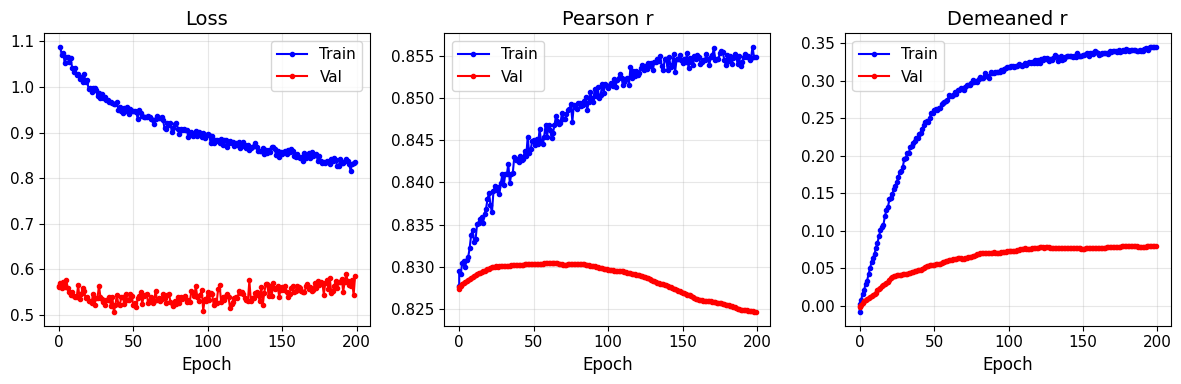

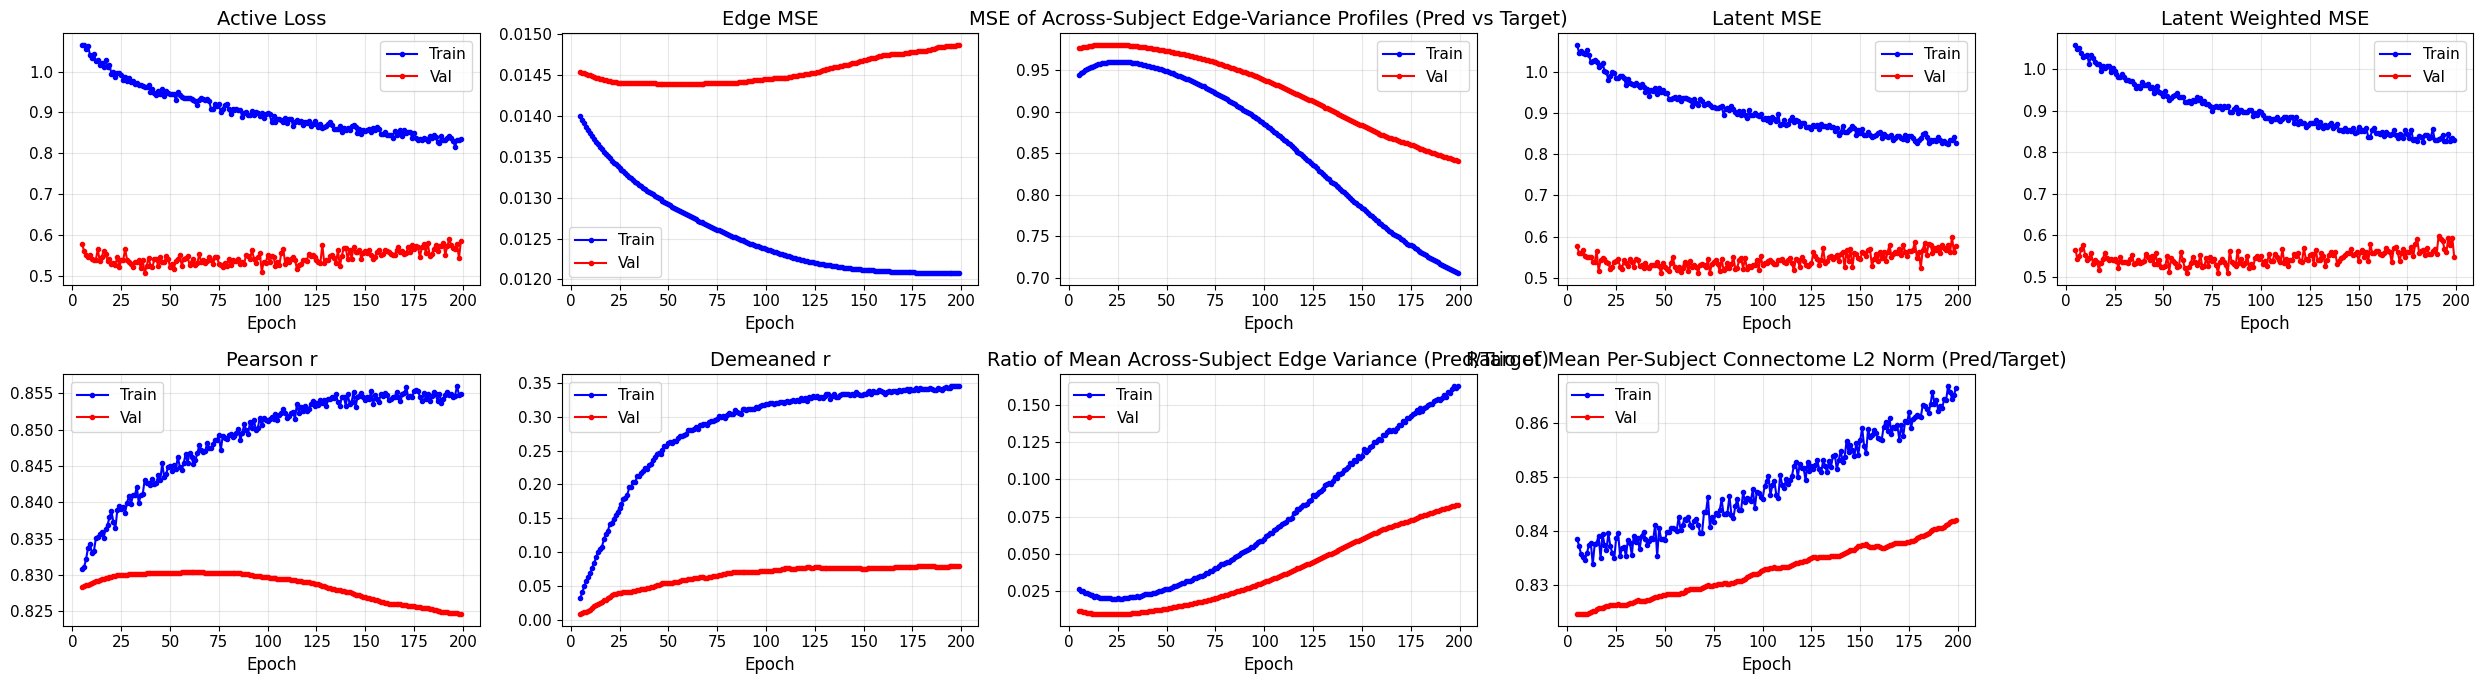

In [26]:
pretrain_config = {
    "model": {
        "n_components_pca": 128,
        "hidden_dim": 128,
        "nonlinear": False,
        "low_rank_dim": None,
        "readout_type": "linear",
        "zscore_pca_scores": True,
        "sc_mask_ratio": 0.2,
        "fc_mask_ratio": 0.2,
        "min_masked_components_per_modality": 1,
        "use_covariates": False,
        "reg": 0,
    },
    "trainer": {
        "max_epochs": 200,
        "lr": 5.0e-4,
        "loss_type": "latent_mse",
    },
}

run_out = sim.run_single(
    mode="dev",
    save_checkpoint=False,
    config_override=pretrain_config,
    run_eval=False,
)
pretrainer_linear = run_out["model"].eval().to(device)
run_out["train_result"].plot(style="latent", skip_first_n_epochs=5)

In [27]:
_ = diagnose_split(pretrainer_linear, sim.train_loader, device, "sc", "train")
_ = diagnose_split(pretrainer_linear, sim.val_loader,   device, "sc", "val")
_ = diagnose_split(pretrainer_linear, sim.train_loader, device, "fc", "train")
_ = diagnose_split(pretrainer_linear, sim.val_loader,   device, "fc", "val")


[diagnose train sc] n=683 k=128
  target mean  : +0.000 ± 0.000 (min -0.000, max +0.000)
  target std   : +1.000 ± 0.000 (min +1.000, max +1.000)
  pred mean    : -0.001 ± 0.009 (min -0.028, max +0.020)
  pred std     : +0.396 ± 0.070 (min +0.301, max +0.834)
  masked MSE   : +0.767 ± 0.084 (min +0.246, max +0.870)
  Pearson r    : +0.485 ± 0.077 (min +0.364, max +0.869)
[diagnose val sc] n=79 k=128
  target mean  : +0.013 ± 0.094 (min -0.214, max +0.262)
  target std   : +0.688 ± 0.074 (min +0.489, max +0.902)
  pred mean    : -0.000 ± 0.047 (min -0.109, max +0.128)
  pred std     : +0.348 ± 0.065 (min +0.258, max +0.699)
  masked MSE   : +0.558 ± 0.101 (min +0.351, max +0.887)
  Pearson r    : +0.094 ± 0.141 (min -0.268, max +0.746)
[diagnose train fc] n=683 k=128
  target mean  : +0.000 ± 0.000 (min -0.000, max +0.000)
  target std   : +1.000 ± 0.000 (min +1.000, max +1.000)
  pred mean    : +0.002 ± 0.009 (min -0.022, max +0.021)
  pred std     : +0.399 ± 0.049 (min +0.289, max +0.

[component-stats sc] device=cuda n=683 k=128
[component-stats sc] j=16/128 elapsed=0.01s
[component-stats sc] j=32/128 elapsed=0.02s
[component-stats sc] j=48/128 elapsed=0.02s
[component-stats sc] j=64/128 elapsed=0.04s
[component-stats sc] j=80/128 elapsed=0.05s
[component-stats sc] j=96/128 elapsed=0.07s
[component-stats sc] j=112/128 elapsed=0.08s
[component-stats sc] j=128/128 elapsed=0.10s
[component-stats sc] done total=0.10s
[component-stats fc] device=cuda n=683 k=128
[component-stats fc] j=16/128 elapsed=0.01s
[component-stats fc] j=32/128 elapsed=0.02s
[component-stats fc] j=48/128 elapsed=0.02s
[component-stats fc] j=64/128 elapsed=0.04s
[component-stats fc] j=80/128 elapsed=0.05s
[component-stats fc] j=96/128 elapsed=0.07s
[component-stats fc] j=112/128 elapsed=0.08s
[component-stats fc] j=128/128 elapsed=0.10s
[component-stats fc] done total=0.10s
[component-stats sc] device=cuda n=79 k=128
[component-stats sc] j=16/128 elapsed=0.01s
[component-stats sc] j=32/128 elapsed=

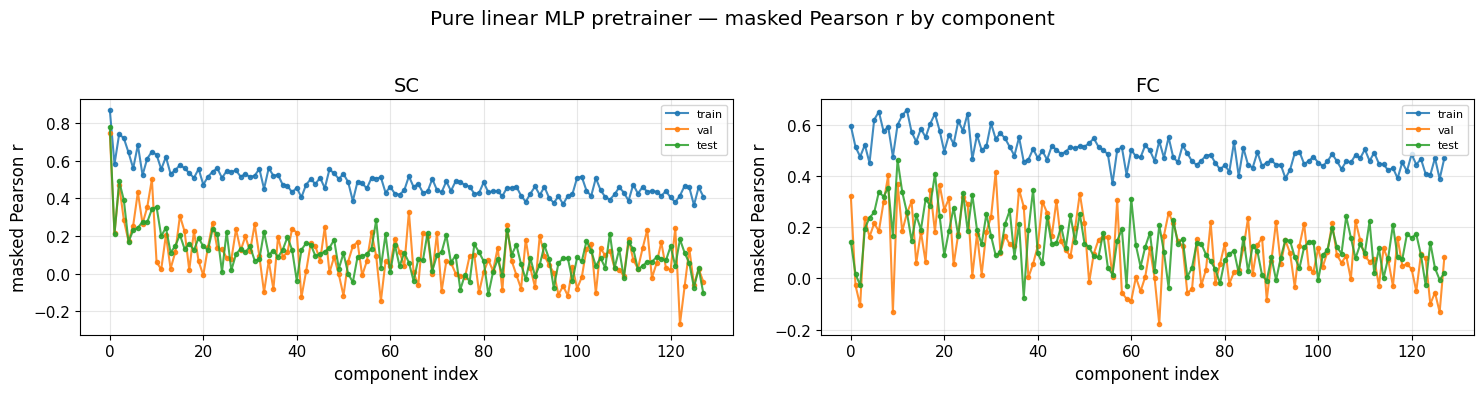

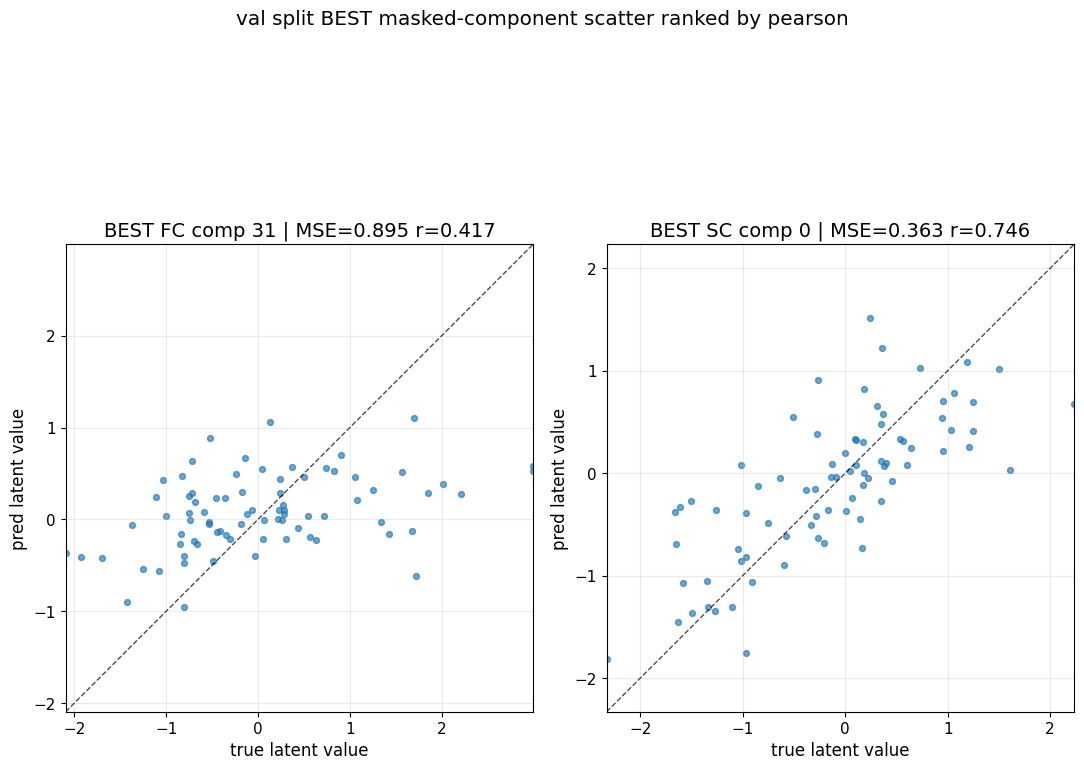

In [28]:
linear_stats = collect_component_stats(
    pretrainer_linear,
    {
        "train": sim.train_loader,
        "val": sim.val_loader,
        "test": sim.test_loader,
    },
    device,
)

plot_component_metric_grid(linear_stats, metric="pearson", title="Pure linear MLP pretrainer — masked Pearson r by component")
plt.show()

linear_scatter_split = "val"
plot_best_worst_component_scatter(
    linear_stats,
    split=linear_scatter_split,
    rank_by="pearson",
    selects=("best",),
    equal_aspect=True,
)
plt.show()


## 2. Low-rank linear

`nonlinear=False` + `low_rank_dim=R`. The encoder is factored `Linear(2k → R, bias=False) ∘ Linear(R → hidden)`. Composition rank ≤ `R`, so this bounds linear capacity from above by the bottleneck. Useful as a sanity anchor — if full-rank linear and low-rank linear land on the same plateau, rank isn't the bottleneck.

MaskedMLPPretrainer init | src=SC tgt=FC | k=128 hidden_dim=128 num_hidden_layers=1 | nonlinear=False low_rank_dim=32 readout=linear | zscore=True sc_p=0.2 fc_p=0.2 | use_cov=False


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type                | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | model | MaskedMLPPretrainer | 45.4 K | train | 0    
--------------------------------------------------------------
45.4 K    Trainable params
0         Non-trainable params
45.4 K    Total params
0.182     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode
0        

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.



Training complete!


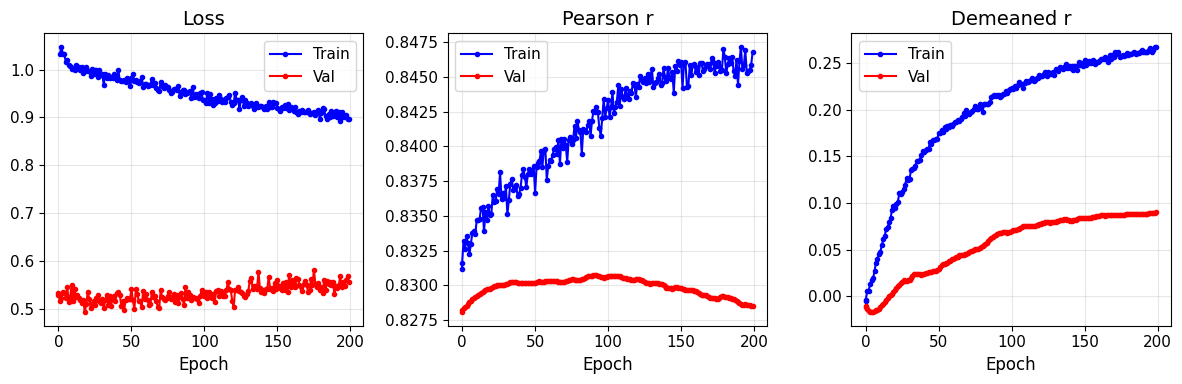

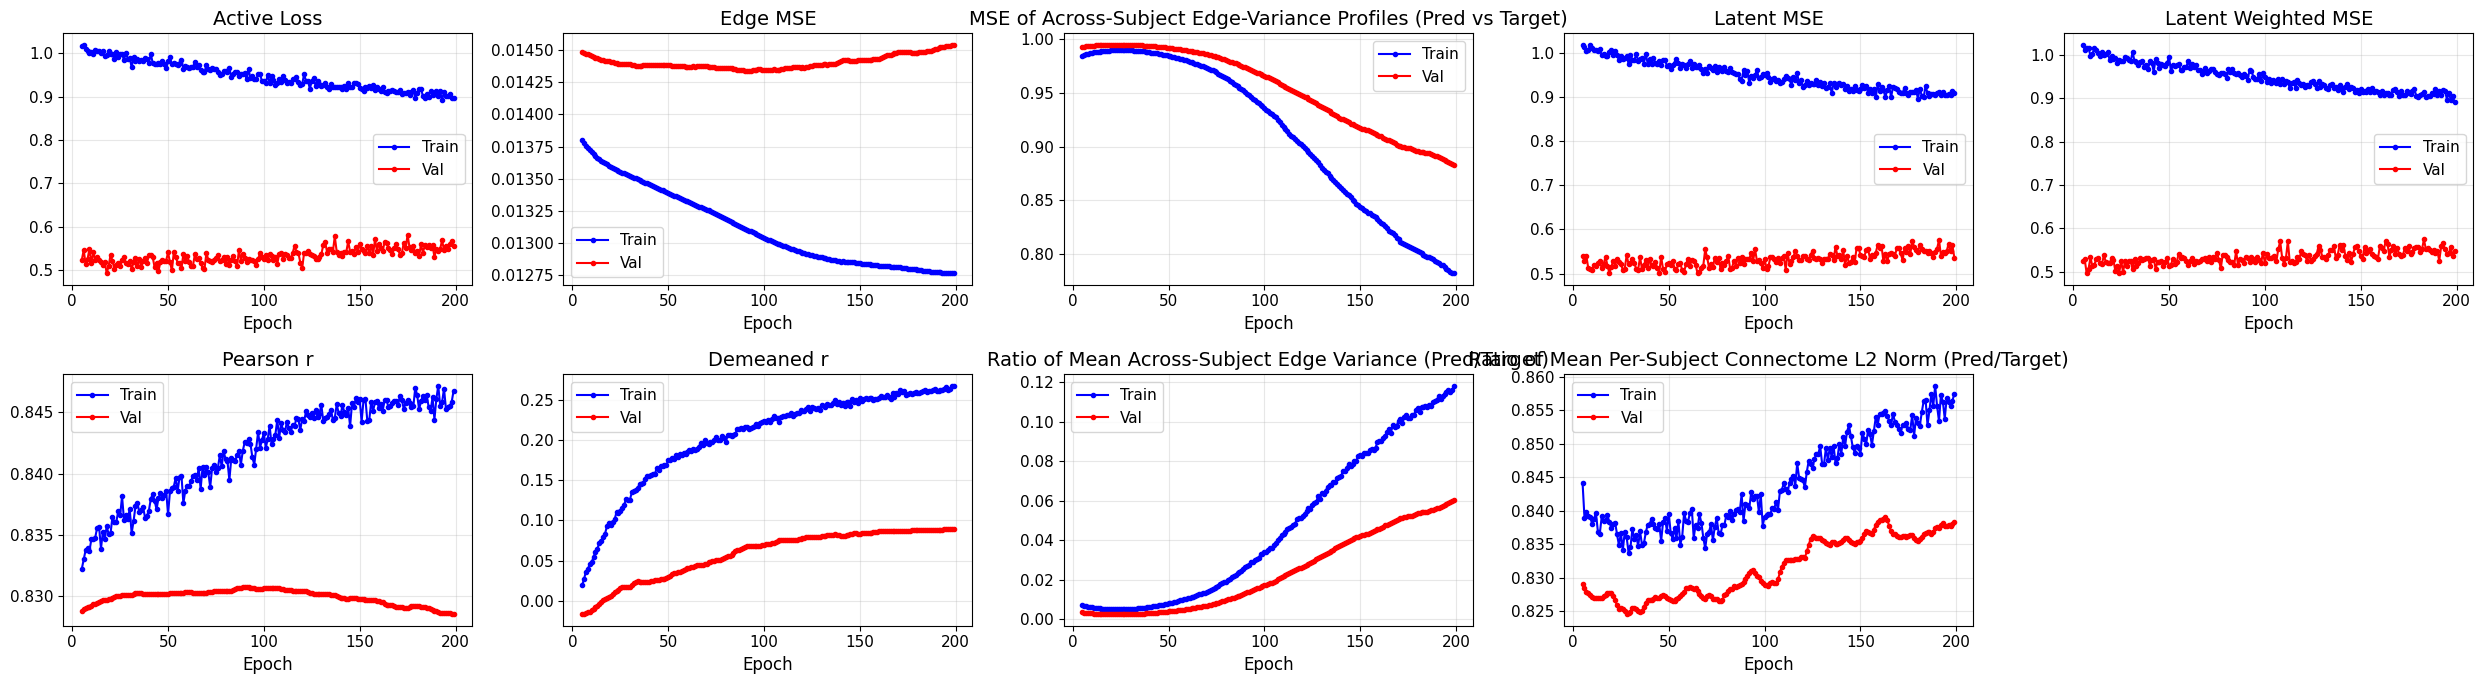

In [29]:
pretrain_config = {
    "model": {
        "n_components_pca": 128,
        "hidden_dim": 128,
        "nonlinear": False,
        "low_rank_dim": 32,
        "readout_type": "linear",
        "zscore_pca_scores": True,
        "sc_mask_ratio": 0.2,
        "fc_mask_ratio": 0.2,
        "min_masked_components_per_modality": 1,
        "use_covariates": False,
        "reg": 0,
    },
    "trainer": {
        "max_epochs": 200,
        "lr": 5.0e-4,
        "loss_type": "latent_mse",
    },
}

run_out = sim.run_single(
    mode="dev",
    save_checkpoint=False,
    config_override=pretrain_config,
    run_eval=False,
)
pretrainer_lowrank = run_out["model"].eval().to(device)
run_out["train_result"].plot(style="latent", skip_first_n_epochs=5)

In [30]:
_ = diagnose_split(pretrainer_lowrank, sim.train_loader, device, "sc", "train")
_ = diagnose_split(pretrainer_lowrank, sim.val_loader,   device, "sc", "val")
_ = diagnose_split(pretrainer_lowrank, sim.train_loader, device, "fc", "train")
_ = diagnose_split(pretrainer_lowrank, sim.val_loader,   device, "fc", "val")


[diagnose train sc] n=683 k=128
  target mean  : +0.000 ± 0.000 (min -0.000, max +0.000)
  target std   : +1.000 ± 0.000 (min +1.000, max +1.000)
  pred mean    : +0.003 ± 0.014 (min -0.040, max +0.040)
  pred std     : +0.273 ± 0.079 (min +0.160, max +0.773)
  masked MSE   : +0.855 ± 0.088 (min +0.271, max +0.953)
  Pearson r    : +0.386 ± 0.098 (min +0.224, max +0.858)
[diagnose val sc] n=79 k=128
  target mean  : +0.013 ± 0.094 (min -0.214, max +0.262)
  target std   : +0.688 ± 0.074 (min +0.489, max +0.902)
  pred mean    : +0.004 ± 0.039 (min -0.123, max +0.087)
  pred std     : +0.286 ± 0.078 (min +0.171, max +0.786)
  masked MSE   : +0.528 ± 0.105 (min +0.321, max +0.888)
  Pearson r    : +0.094 ± 0.142 (min -0.230, max +0.744)
[diagnose train fc] n=683 k=128
  target mean  : +0.000 ± 0.000 (min -0.000, max +0.000)
  target std   : +1.000 ± 0.000 (min +1.000, max +1.000)
  pred mean    : +0.002 ± 0.015 (min -0.042, max +0.037)
  pred std     : +0.284 ± 0.052 (min +0.189, max +0.

[component-stats sc] device=cuda n=683 k=128
[component-stats sc] j=16/128 elapsed=0.01s
[component-stats sc] j=32/128 elapsed=0.02s
[component-stats sc] j=48/128 elapsed=0.03s
[component-stats sc] j=64/128 elapsed=0.04s
[component-stats sc] j=80/128 elapsed=0.06s
[component-stats sc] j=96/128 elapsed=0.07s
[component-stats sc] j=112/128 elapsed=0.09s
[component-stats sc] j=128/128 elapsed=0.10s
[component-stats sc] done total=0.10s
[component-stats fc] device=cuda n=683 k=128
[component-stats fc] j=16/128 elapsed=0.01s
[component-stats fc] j=32/128 elapsed=0.02s
[component-stats fc] j=48/128 elapsed=0.03s
[component-stats fc] j=64/128 elapsed=0.04s
[component-stats fc] j=80/128 elapsed=0.06s
[component-stats fc] j=96/128 elapsed=0.07s
[component-stats fc] j=112/128 elapsed=0.09s
[component-stats fc] j=128/128 elapsed=0.10s
[component-stats fc] done total=0.10s
[component-stats sc] device=cuda n=79 k=128
[component-stats sc] j=16/128 elapsed=0.01s
[component-stats sc] j=32/128 elapsed=

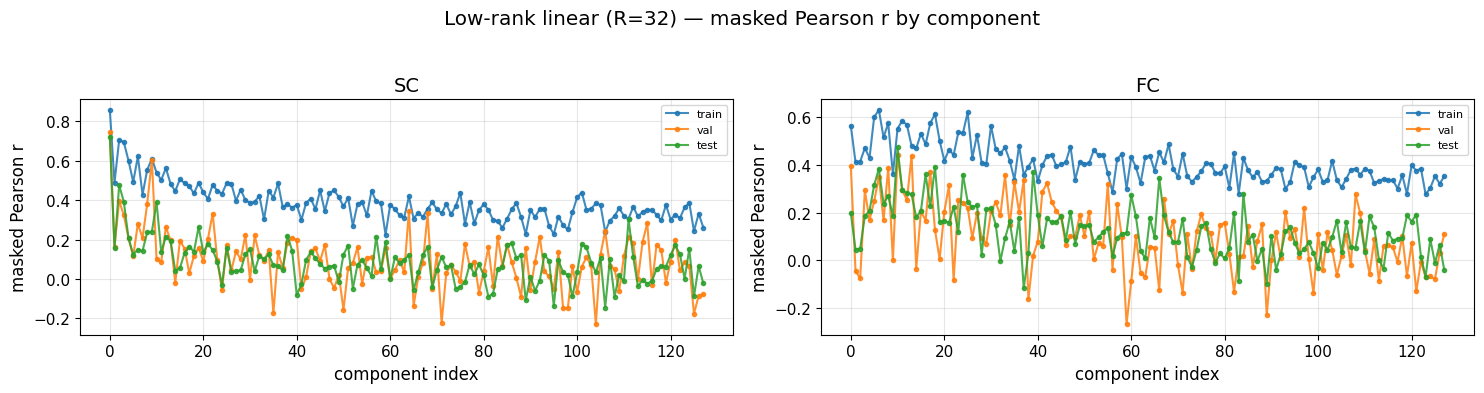

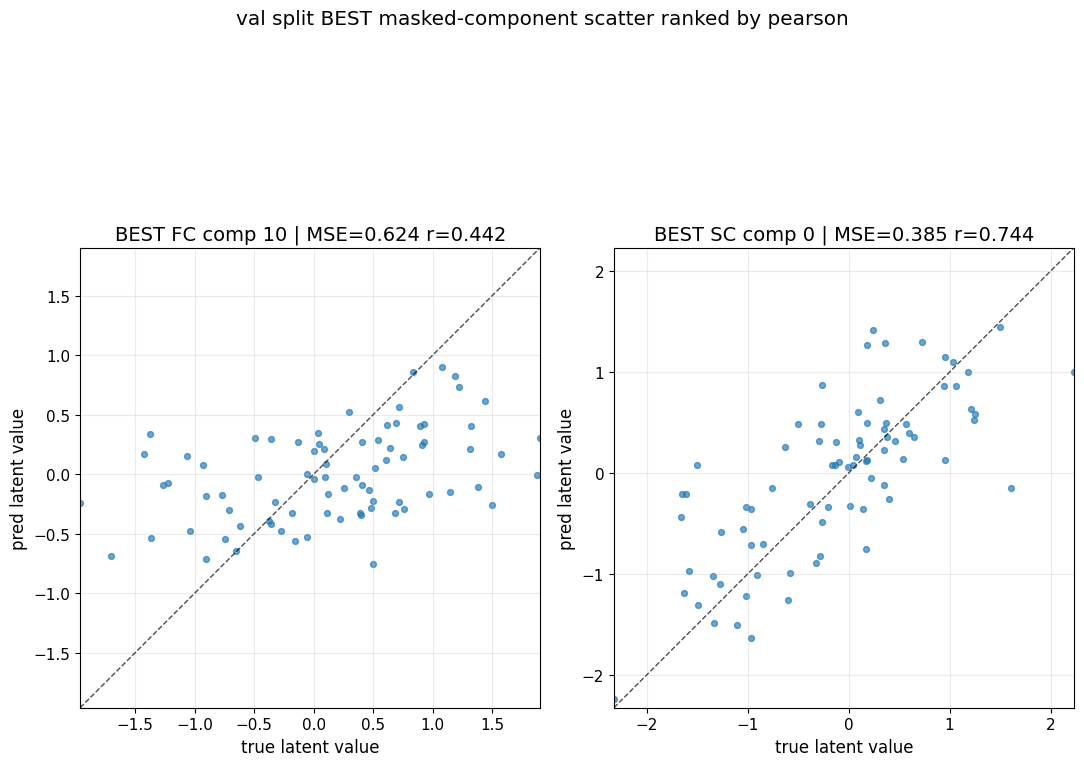

In [31]:
lowrank_stats = collect_component_stats(
    pretrainer_lowrank,
    {
        "train": sim.train_loader,
        "val": sim.val_loader,
        "test": sim.test_loader,
    },
    device,
)

plot_component_metric_grid(lowrank_stats, metric="pearson", title="Low-rank linear (R=32) — masked Pearson r by component")
plt.show()

lowrank_scatter_split = "val"
plot_best_worst_component_scatter(
    lowrank_stats,
    split=lowrank_scatter_split,
    rank_by="pearson",
    selects=("best",),
    equal_aspect=True,
)
plt.show()


## 3. Nonlinear MLP

`nonlinear=True`, two hidden layers, MLP readout heads. Deliberately over-parameterized to test whether capacity above linear helps. If this plateau matches the linear one, PCA decorrelation is the ceiling; if it breaks below, the attention model was under-trained.

MaskedMLPPretrainer init | src=SC tgt=FC | k=128 hidden_dim=256 num_hidden_layers=2 | nonlinear=True low_rank_dim=None readout=mlp | zscore=True sc_p=0.2 fc_p=0.2 | use_cov=False


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type                | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | model | MaskedMLPPretrainer | 230 K  | train | 0    
--------------------------------------------------------------
230 K     Trainable params
0         Non-trainable params
230 K     Total params
0.922     Total estimated model params size (MB)
16        Modules in train mode
0         Modules in eval mode
0        

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.



Training complete!


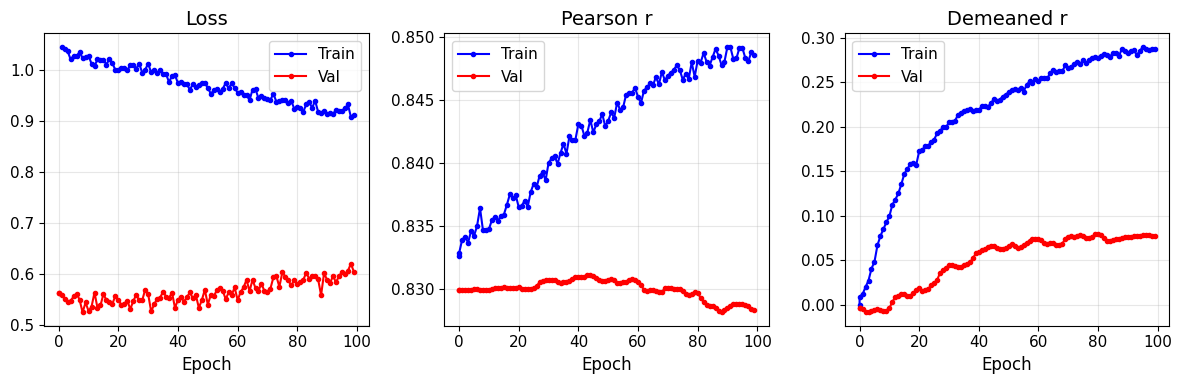

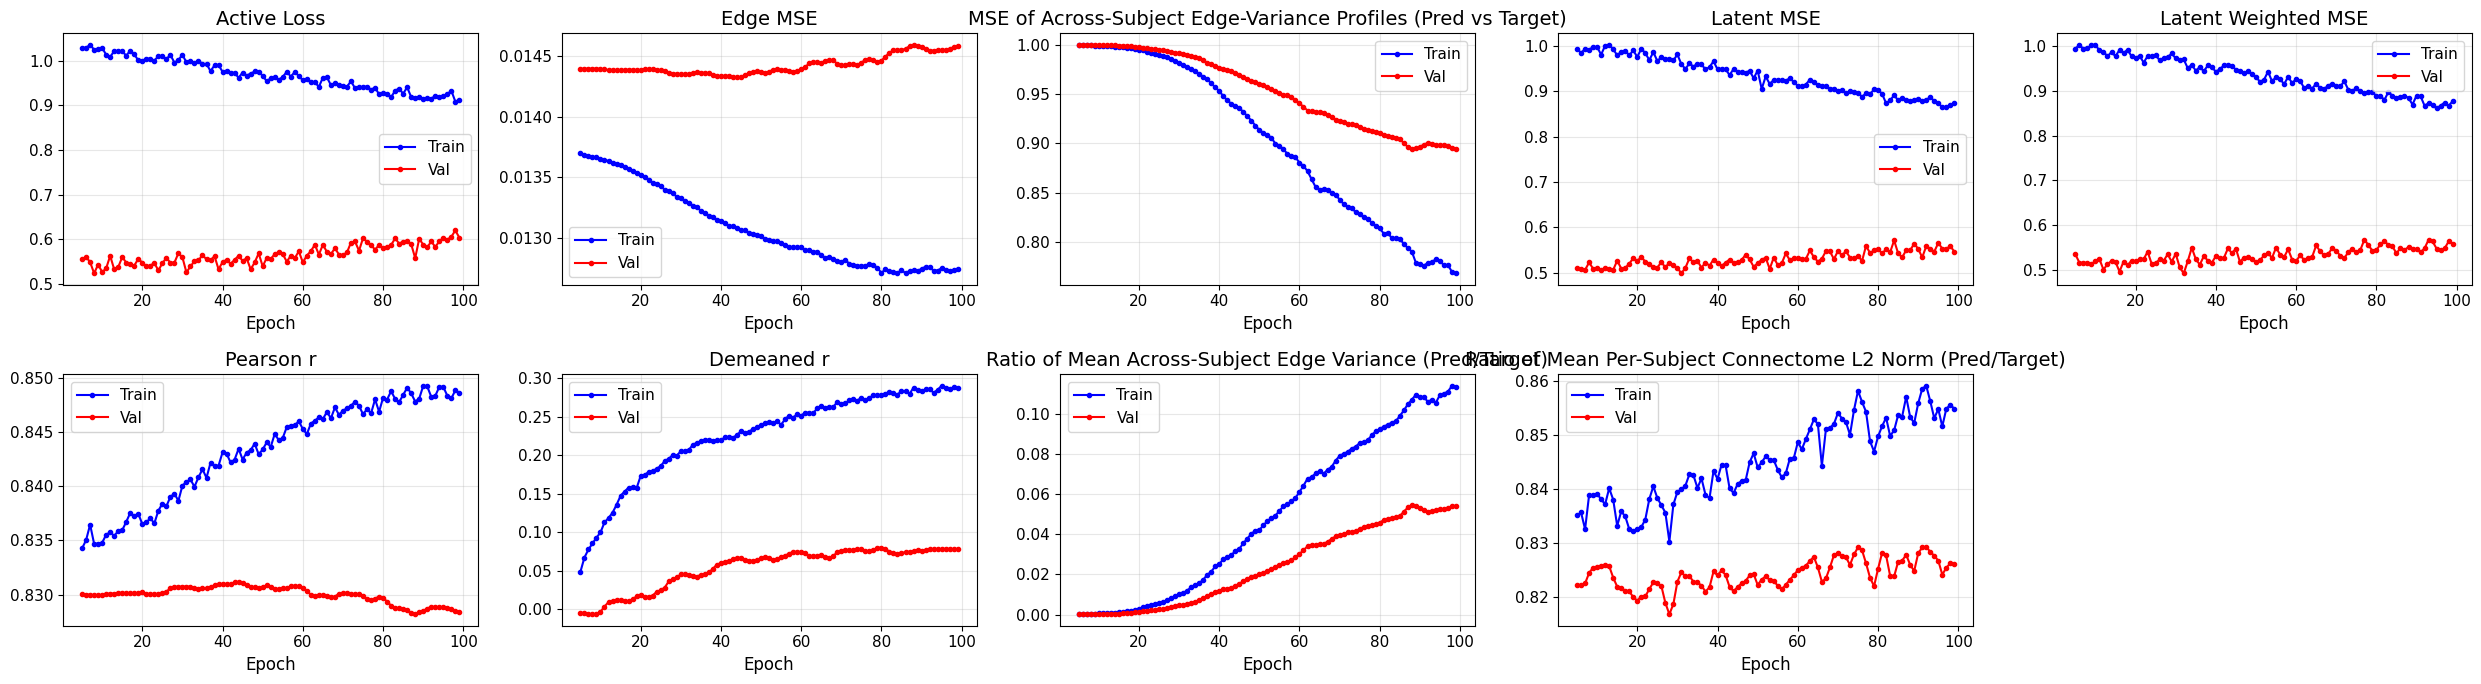

In [32]:
pretrain_config = {
    "model": {
        "n_components_pca": 128,
        "hidden_dim": 256,
        "num_hidden_layers": 2,
        "dropout": 0.2,
        "nonlinear": True,
        "readout_type": "mlp",
        "readout_hidden_dim": 128,
        "zscore_pca_scores": True,
        "sc_mask_ratio": 0.2,
        "fc_mask_ratio": 0.2,
        "min_masked_components_per_modality": 1,
        "use_covariates": False,
        "reg": 1.0e-4,
    },
    "trainer": {
        "max_epochs": 100,
        "lr": 1.0e-3,
        "loss_type": "latent_mse",
    },
}

run_out = sim.run_single(
    mode="dev",
    save_checkpoint=False,
    config_override=pretrain_config,
    run_eval=False,
)
pretrainer_mlp = run_out["model"].eval().to(device)
run_out["train_result"].plot(style="latent", skip_first_n_epochs=5)

[diagnose train sc] n=683 k=128
  target mean  : +0.000 ± 0.000 (min -0.000, max +0.000)
  target std   : +1.000 ± 0.000 (min +1.000, max +1.000)
  pred mean    : -0.005 ± 0.041 (min -0.097, max +0.085)
  pred std     : +0.286 ± 0.074 (min +0.182, max +0.705)
  masked MSE   : +0.768 ± 0.097 (min +0.228, max +0.895)
  Pearson r    : +0.539 ± 0.090 (min +0.373, max +0.900)
[diagnose val sc] n=79 k=128
  target mean  : +0.013 ± 0.094 (min -0.214, max +0.262)
  target std   : +0.688 ± 0.074 (min +0.489, max +0.902)
  pred mean    : -0.008 ± 0.058 (min -0.190, max +0.167)
  pred std     : +0.292 ± 0.071 (min +0.174, max +0.698)
  masked MSE   : +0.532 ± 0.099 (min +0.306, max +0.802)
  Pearson r    : +0.096 ± 0.141 (min -0.223, max +0.714)
[diagnose train fc] n=683 k=128
  target mean  : +0.000 ± 0.000 (min -0.000, max +0.000)
  target std   : +1.000 ± 0.000 (min +1.000, max +1.000)
  pred mean    : -0.000 ± 0.039 (min -0.082, max +0.107)
  pred std     : +0.290 ± 0.054 (min +0.158, max +0.

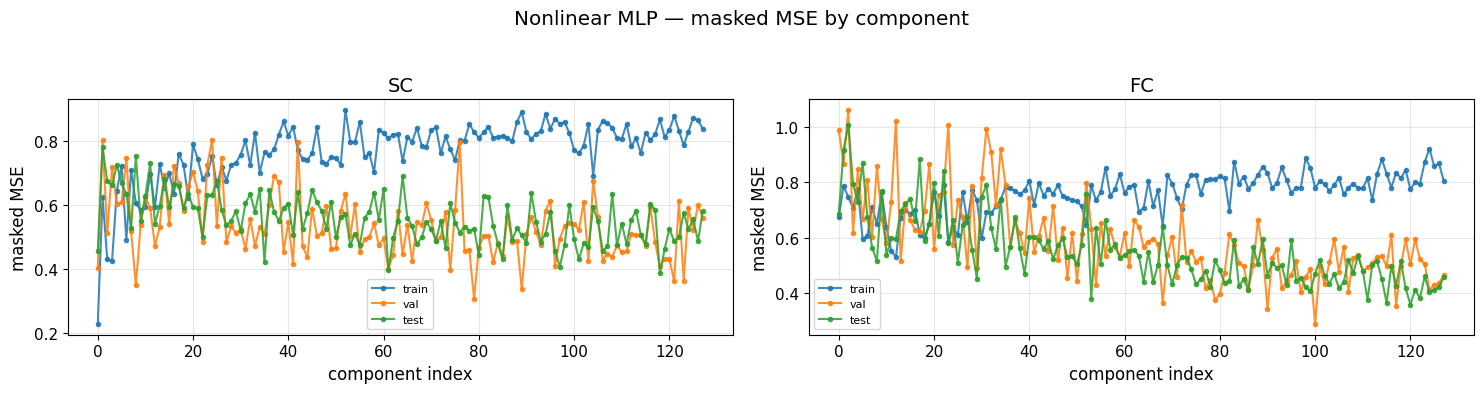

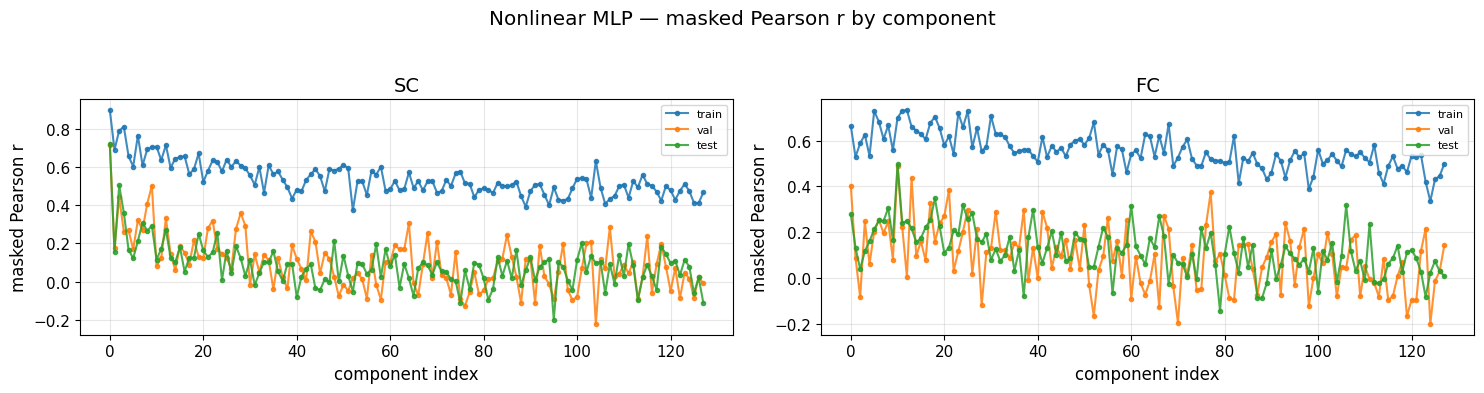

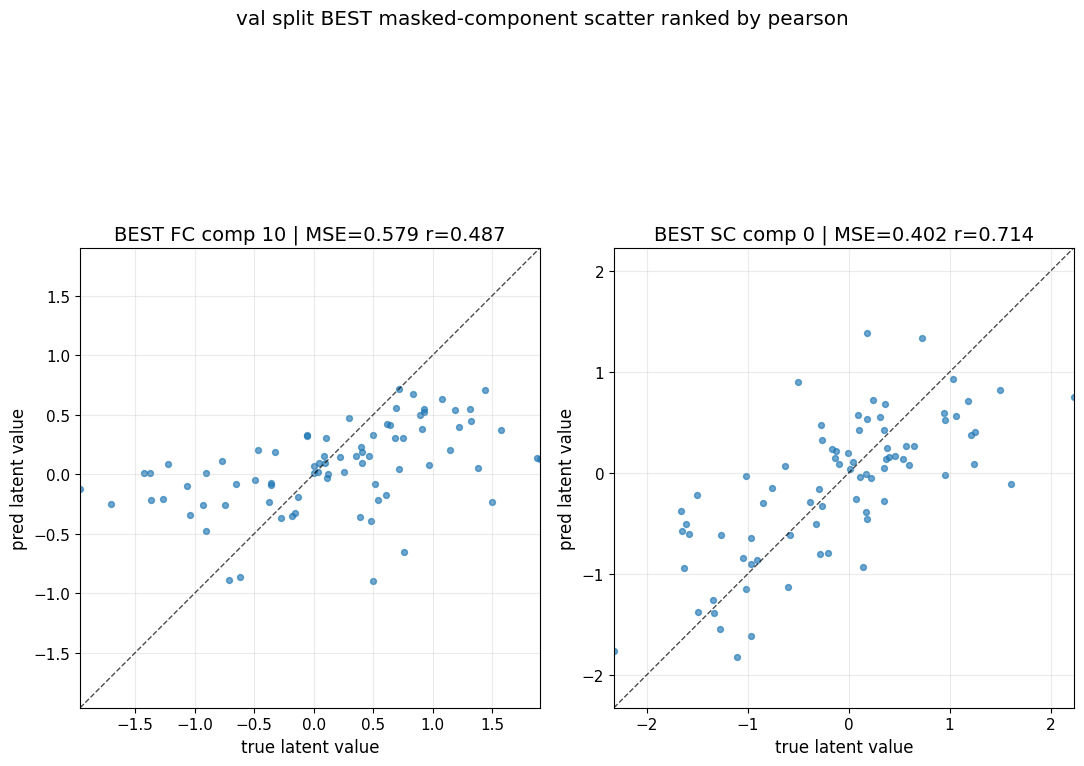

In [36]:
_ = diagnose_split(pretrainer_mlp, sim.train_loader, device, "sc", "train")
_ = diagnose_split(pretrainer_mlp, sim.val_loader,   device, "sc", "val")
_ = diagnose_split(pretrainer_mlp, sim.train_loader, device, "fc", "train")
_ = diagnose_split(pretrainer_mlp, sim.val_loader,   device, "fc", "val")

mlp_stats = collect_component_stats(
    pretrainer_mlp,
    {
        "train": sim.train_loader,
        "val": sim.val_loader,
        "test": sim.test_loader,
    },
    device,
)

plot_component_metric_grid(mlp_stats, metric="mse", title="Nonlinear MLP — masked MSE by component")
plt.show()

plot_component_metric_grid(mlp_stats, metric="pearson", title="Nonlinear MLP — masked Pearson r by component")
plt.show()

mlp_scatter_split = "val"
plot_best_worst_component_scatter(
    mlp_stats,
    split=mlp_scatter_split,
    rank_by="pearson",
    selects=("best",),
    equal_aspect=True,
)
plt.show()


## Interpreting validation metrics: training vs. zero-shot evaluation

**Training loss** (`compute_latent_loss`): Computed with random joint masks per batch (~15% SC + ~15% FC). Measures MSE on held-out positions only, in PCA score space, using mixed-modality context.

**Validation edge metrics** (`val_pearson_r`, `val_demeaned_r`): Obtained from `forward(x)`, which uses a test-time masking pattern the model is *never explicitly trained on*:

> All FC components masked, all SC components visible &rarr; encoder &rarr; `fc_readout_head` &rarr; `decode_target_latents` &rarr; FC edge space

This serves as a zero-shot SC→FC downstream analog, testing whether the self-supervised objective implicitly encouraged learning a cross-modal mapping.

- `val_demeaned_r`: Pearson r between predicted and true FC edges, after subtracting the across-subject mean at each edge. This ignores trivial population-mean FC effects and only credits **subject-specific** FC variation recovered from SC alone.

**Why does `val_demeaned_r` often stay near zero even as `val_latent_mse` decreases?**  
During training, it's easy for the model to (a) copy visible FC context to reconstruct held-out FC, and (b) do within-modality SC→SC reconstruction (which is degenerate due to PCA decorrelation). The first effect (a) tends to dominate. At validation, `forward(x)` disables (a) by masking *all* FC, so the model must rely entirely on any SC↔FC cross-modal coupling learned as a side effect. If this coupling is weak (i.e., masked-MSE plateaus near 0.5), then demeaned_r remains near zero.

**How to read these metrics together:**
- `val_latent_mse`: Indicates how well the pretraining task itself is being solved.
- `val_demeaned_r`: Shows how well the learned SC↔FC coupling generalizes to pure SC→FC inference in a zero-shot setting. (This is especially relevant if planning to transfer weights without fine-tuning.)

For this MLP variant, success looks like both `val_latent_mse` dropping **and** `val_demeaned_r` climbing above zero—evidence that the model is learning a true cross-modal map, not just copying within-modality context.

## Cross-model comparison

Show each split on its own figure so the relative model ordering is easier to read. Color now only distinguishes model family; train, val, and test are separated into different plots.


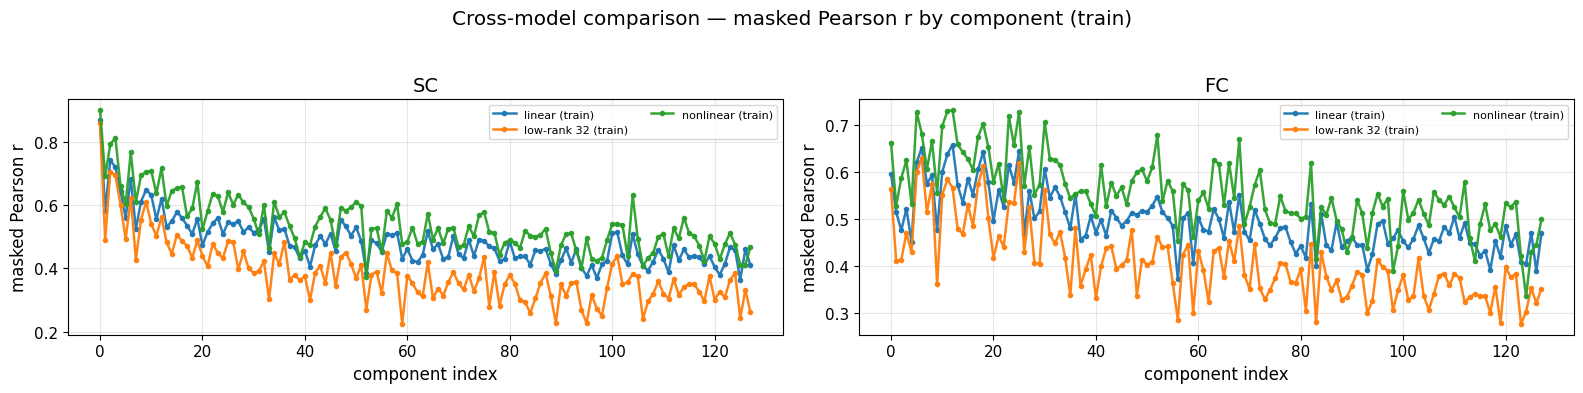

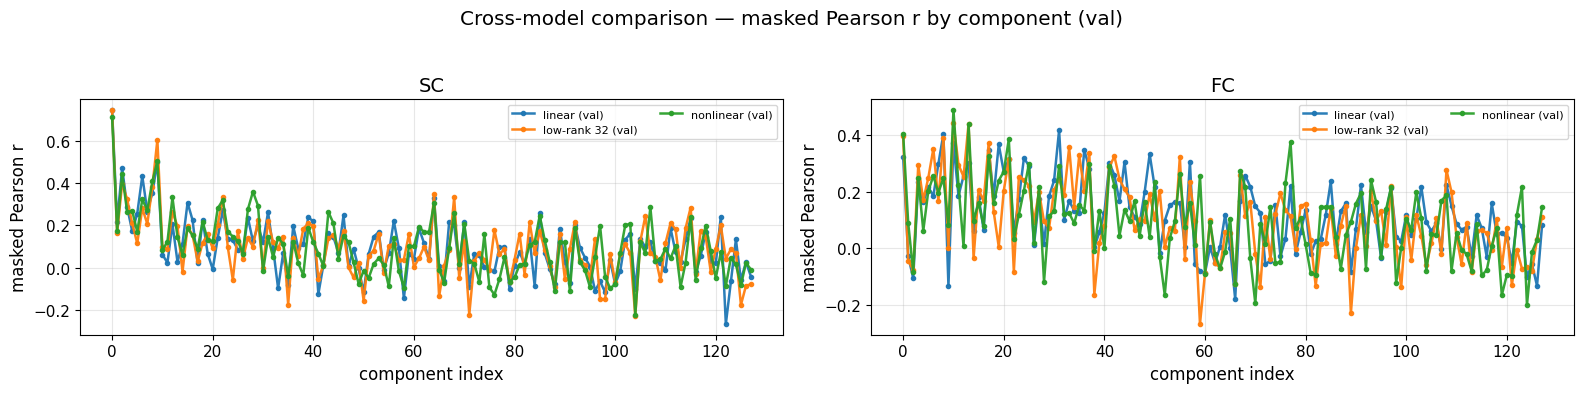

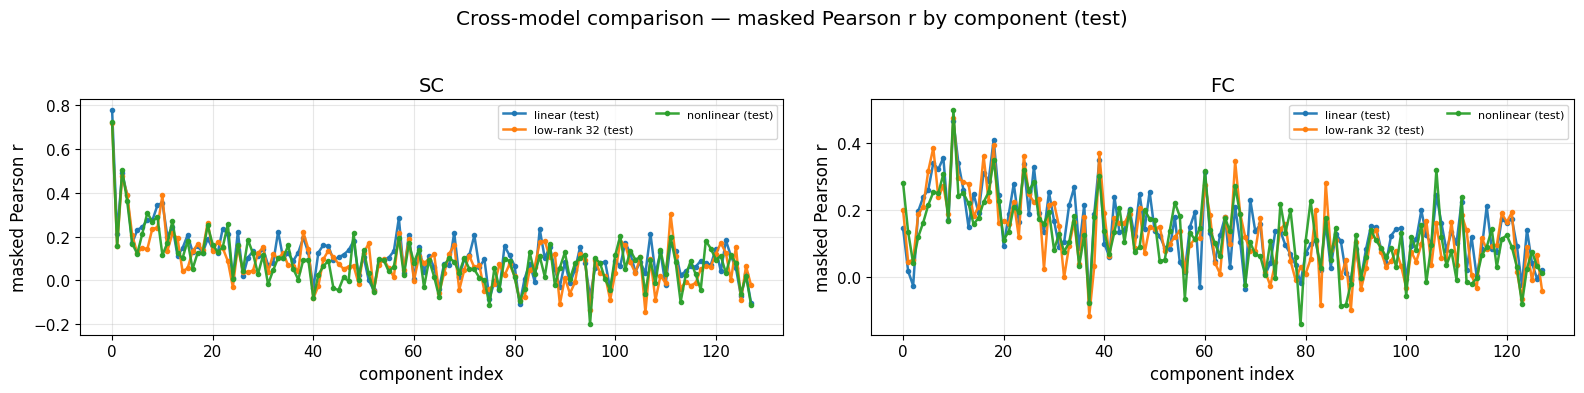

In [38]:
for split in ("train", "val", "test"):
    plot_cross_model_component_metric(
        model_stats,
        metric="pearson",
        splits=(split,),
        title=f"Cross-model comparison — masked Pearson r by component ({split})",
    )
    plt.show()
